# 19.4) Preço das Casas Regressão com Redes Neurais

In [149]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
base_casas = pd.read_csv('../13-Regressao/house_prices.csv')
base_casas.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [150]:
base_casas.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [151]:
# data da publicação do preço (date)
# price - preço
# sqft_living - metragem quadrada do local, casa apt. (sua atualização - sqft_living15)
# sqft_lot - metragem quadrada do lote.  (sua atualização - sqft_lot15)
# floors - quantidade dos andares.
# condition- condição da casa.
# grade - nota da casa.
# yr_built - ano construida.
# yr_renovated - ano renovada.
# zipcode - cep.


In [152]:
base_casas.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Primeiro quartil 25% da base de dados.

Terceiro Quartil 75% da base de dados.

Segundo Quartil 50% da base de dados. -> ou a mediana.

mean - média

Verificar atributos faltantes

In [153]:
list(base_casas.columns)

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15']

In [154]:
list(base_casas.columns)[3:19] # coletar os dados até a longitude, começando dos quartos.

['bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long']

In [155]:
len(list(base_casas.columns)[3:19]) #quantidade de colunas do x

16

In [156]:
# selecionar todas as linhas [:,
# selecionar as colundas da 3 à 19 iloc[:, 3:19]
# atributos abaixo selecionados.
X_casas = base_casas.iloc[:, 3:19].values
X_casas

array([[ 3.00000e+00,  1.00000e+00,  1.18000e+03, ...,  9.81780e+04,
         4.75112e+01, -1.22257e+02],
       [ 3.00000e+00,  2.25000e+00,  2.57000e+03, ...,  9.81250e+04,
         4.77210e+01, -1.22319e+02],
       [ 2.00000e+00,  1.00000e+00,  7.70000e+02, ...,  9.80280e+04,
         4.77379e+01, -1.22233e+02],
       ...,
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75944e+01, -1.22299e+02],
       [ 3.00000e+00,  2.50000e+00,  1.60000e+03, ...,  9.80270e+04,
         4.75345e+01, -1.22069e+02],
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ...,  9.81440e+04,
         4.75941e+01, -1.22299e+02]])

In [157]:
list(base_casas.columns)[2] # coletar o dado de y, no caso a previsão do preço

'price'

In [158]:
y_casas = base_casas.iloc[:, 2].values
y_casas

array([221900., 538000., 180000., ..., 402101., 400000., 325000.])

In [159]:
# vamos prever os preços, para isso vamos separar bases dos treinos.

from sklearn.model_selection import train_test_split
X_casas_treinamento, X_casas_teste, y_casas_treinamento, y_casas_teste = train_test_split(X_casas, y_casas, test_size = 0.3, random_state = 0)

## Base preço das casas 

In [160]:
X_casas_treinamento.shape # treinar o algoritmo.

(15129, 16)

In [161]:
X_casas_treinamento

array([[ 4.00000e+00,  1.50000e+00,  1.39000e+03, ...,  9.81330e+04,
         4.77224e+01, -1.22332e+02],
       [ 3.00000e+00,  1.50000e+00,  1.45000e+03, ...,  9.81330e+04,
         4.77725e+01, -1.22349e+02],
       [ 5.00000e+00,  2.75000e+00,  2.86000e+03, ...,  9.80520e+04,
         4.77082e+01, -1.22104e+02],
       ...,
       [ 3.00000e+00,  2.25000e+00,  2.36000e+03, ...,  9.80420e+04,
         4.73856e+01, -1.22158e+02],
       [ 4.00000e+00,  2.00000e+00,  2.37000e+03, ...,  9.80010e+04,
         4.72831e+01, -1.22279e+02],
       [ 4.00000e+00,  2.25000e+00,  2.38000e+03, ...,  9.80080e+04,
         4.76126e+01, -1.22120e+02]])

In [162]:
y_casas_treinamento  # preço real das casas

array([400000., 430000., 720000., ..., 431000., 411000., 699900.])

In [163]:
X_casas_teste # conjunto de registros para o teste.

array([[ 2.00000e+00,  1.50000e+00,  1.43000e+03, ...,  9.81250e+04,
         4.77222e+01, -1.22290e+02],
       [ 4.00000e+00,  3.25000e+00,  4.67000e+03, ...,  9.80050e+04,
         4.76350e+01, -1.22164e+02],
       [ 2.00000e+00,  7.50000e-01,  1.44000e+03, ...,  9.81070e+04,
         4.76707e+01, -1.22364e+02],
       ...,
       [ 3.00000e+00,  2.50000e+00,  2.15000e+03, ...,  9.80580e+04,
         4.74514e+01, -1.22089e+02],
       [ 3.00000e+00,  1.75000e+00,  1.48000e+03, ...,  9.80320e+04,
         4.73657e+01, -1.22280e+02],
       [ 3.00000e+00,  1.00000e+00,  1.32000e+03, ...,  9.80920e+04,
         4.73120e+01, -1.22183e+02]])

In [164]:
X_casas_teste.shape # testar o algoritmo. 

(6484, 16)

In [165]:
from sklearn.preprocessing import StandardScaler # biblioteca para criar o objeto
scaler_x_casas = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
X_casas_treinamento_scaled = scaler_x_casas.fit_transform(X_casas_treinamento)
scaler_y_casas = StandardScaler() # método para padronizar ou normalizar os dados com a média e o desvio padrão. 
y_casas_treinamento_scaled = scaler_y_casas.fit_transform(y_casas_treinamento.reshape(-1,1)) # apenas os pereços no y
# estava em formato de vetor e temos que transformar em matriz.

In [166]:
# treinar as redes neurais

In [167]:
X_casas_treinamento_scaled # valores escalonados, se comparados com os dados originais

array([[ 0.67170039, -0.79711466, -0.74522967, ...,  1.03727271,
         1.17348387, -0.83797629],
       [-0.38696772, -0.79711466, -0.68028398, ...,  1.03727271,
         1.53476983, -0.95879989],
       [ 1.7303685 ,  0.82292131,  0.84593978, ..., -0.48008241,
         1.07108346,  0.78248142],
       ...,
       [-0.38696772,  0.17490692,  0.30472568, ..., -0.66741021,
        -1.25528083,  0.3986888 ],
       [ 0.67170039, -0.14910028,  0.31554996, ..., -1.43545415,
        -1.99443873, -0.46129094],
       [ 0.67170039,  0.17490692,  0.32637425, ..., -1.3043247 ,
         0.38168351,  0.66876509]])

In [168]:
X_casas_treinamento

array([[ 4.00000e+00,  1.50000e+00,  1.39000e+03, ...,  9.81330e+04,
         4.77224e+01, -1.22332e+02],
       [ 3.00000e+00,  1.50000e+00,  1.45000e+03, ...,  9.81330e+04,
         4.77725e+01, -1.22349e+02],
       [ 5.00000e+00,  2.75000e+00,  2.86000e+03, ...,  9.80520e+04,
         4.77082e+01, -1.22104e+02],
       ...,
       [ 3.00000e+00,  2.25000e+00,  2.36000e+03, ...,  9.80420e+04,
         4.73856e+01, -1.22158e+02],
       [ 4.00000e+00,  2.00000e+00,  2.37000e+03, ...,  9.80010e+04,
         4.72831e+01, -1.22279e+02],
       [ 4.00000e+00,  2.25000e+00,  2.38000e+03, ...,  9.80080e+04,
         4.76126e+01, -1.22120e+02]])

In [169]:
y_casas_treinamento_scaled # base de dados y que é padronizados também. 

array([[-0.38454326],
       [-0.3024967 ],
       [ 0.49062008],
       ...,
       [-0.29976181],
       [-0.35445952],
       [ 0.43564888]])

In [170]:
y_casas_treinamento

array([400000., 430000., 720000., ..., 431000., 411000., 699900.])

In [171]:
X_casas_treinamento_scaled.shape, y_casas_treinamento_scaled.shape

((15129, 16), (15129, 1))

In [172]:
# método para padronizar ou normalizar os dados com a média e o desvio padrão. 
X_casas_teste_scaled = scaler_x_casas.transform(X_casas_teste)
# método para padronizar ou normalizar os dados com a média e o desvio padrão. 
y_casas_teste_scaled = scaler_y_casas.transform(y_casas_teste.reshape(-1,1))
# estava em formato de vetor e temos que transformar em matriz. => .reshape(-1,1). Para conseguir usar a classe scaler

In [173]:
X_casas_teste_scaled

array([[-1.44563583, -0.79711466, -0.70193254, ...,  0.88741047,
         1.17204161, -0.53947092],
       [ 0.67170039,  1.47093569,  2.80513482, ..., -1.36052304,
         0.54321655,  0.35604518],
       [-1.44563583, -1.76913625, -0.69110826, ...,  0.55022044,
         0.80065984, -1.06540895],
       ...,
       [-0.38696772,  0.49891411,  0.07741576, ..., -0.36768574,
        -0.78077751,  0.88909048],
       [-0.38696772, -0.47310747, -0.64781113, ..., -0.854738  ,
        -1.39878563, -0.46839822],
       [-0.38696772, -1.44512905, -0.82099964, ...,  0.26922876,
        -1.78603226,  0.22100704]])

In [174]:
X_casas_teste_scaled.shape, y_casas_teste_scaled.shape

((6484, 16), (6484, 1))

In [175]:
y_casas_teste_scaled

array([[-0.66623646],
       [ 2.83715179],
       [ 0.05878167],
       ...,
       [-0.43924097],
       [-0.74554814],
       [-0.91511104]])

In [176]:
# [número de atributos (16) + um atributo (que no caso queremos prever apenas o preço) ]/ 2

(16 + 1) / 2   # ARREDONDAMOS PARA 9 , no geral 2 camadas ocultas são suficientes

# na classificação das imagens, podemos ter centenas de camadas. 

8.5

In [177]:
from sklearn.neural_network import MLPRegressor
# número de atributos 16 neurônios na camada de entredada-> 9 neurônios na camada oculta -> 
# 9 neurônios na camada oculta -> 1 neurônio na camada de saída. 
# 16 -> 9 -> 9 -> 1
regressor_rna_casas = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9)) 
# reprocessar por 1000 décadas
# definir 2 camadas ocultas, com 9 Neurônios cada, hidden_layer_sizes=(9,9)
regressor_rna_casas.fit(X_casas_treinamento_scaled, y_casas_treinamento_scaled.ravel()) # treinar

#. ravel para ser 1 dimensão só 

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [178]:
regressor_rna_casas.get_params()

{'activation': 'relu',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': (9, 9),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 1000,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': False,
 'warm_start': False}

In [179]:
regressor_rna_casas.score(X_casas_treinamento_scaled, y_casas_treinamento_scaled)

0.8854784260347781

In [180]:
 y_casas_treinamento_scaled.ravel() # vetor

array([-0.38454326, -0.3024967 ,  0.49062008, ..., -0.29976181,
       -0.35445952,  0.43564888])

In [181]:
y_casas_treinamento_scaled # matriz

array([[-0.38454326],
       [-0.3024967 ],
       [ 0.49062008],
       ...,
       [-0.29976181],
       [-0.35445952],
       [ 0.43564888]])

In [182]:
qualidade_algoritmo_treinamento = regressor_rna_casas.score(X_casas_treinamento_scaled, y_casas_treinamento_scaled)

print('A acurácia do modelo Redes Neurais com regressão é de {:.1f}% para o treinamento.'.format(qualidade_algoritmo_treinamento*100)) 
# quanto mais perto de 1, melhor é esse valor.

A acurácia do modelo Redes Neurais com regressão é de 88.5% para o treinamento.


In [183]:
regressor_rna_casas.score(X_casas_teste_scaled, y_casas_teste_scaled)

0.8735961081623106

In [184]:
qualidade_algoritmo_teste = regressor_rna_casas.score(X_casas_teste_scaled, y_casas_teste_scaled)


print('A acurácia do modelo Redes Neurais com regressão é de {:.1f}% para o teste.'.format(qualidade_algoritmo_teste*100)) 
# quanto mais perto de 1, melhor é esse valor.

A acurácia do modelo Redes Neurais com regressão é de 87.4% para o teste.


In [185]:
#BASE PREÇO DAS CASAS
# melhor análise é pela acurácia do teste.

#Acurácia na regressão linear simples de: 49.5% e 48.9% treino e teste
#Acurácia na regressão linear múltipla de: 70 e 68% treino e teste
#Acurácia na regressão linear Polinomial de: 79,2% a 79,5% treino e teste
#Acurácia na regressão linear Com árvore de decisão: 99,9% e 70,3% treino e teste
#Acurácia na regressão linear Com random forest: 98% e 88% treino e teste => pelo teste este é o melhor modelo
#Acurácia na regressão linear Com SVR: 81% e 74% treino e teste 
#Acurácia na regressão linear Com Redes Neurais: 90% e 89% treino e teste   => pelo teste este é o melhor modelo (parecido com o random forest)


In [186]:
##previsoes = regressor_rna_casas.predict(X_casas_teste_scaled) -- Atualizado 17/08/2022 -- Inclusão .reshape(-1, 1)
##previsoes

In [187]:
previsoes = regressor_rna_casas.predict(X_casas_teste_scaled).reshape(-1, 1)
previsoes # previsores

array([[-0.57845647],
       [ 3.39637868],
       [ 0.04280761],
       ...,
       [-0.54027587],
       [-0.81113713],
       [-0.83174248]])

In [188]:
y_casas_teste_scaled #reais

array([[-0.66623646],
       [ 2.83715179],
       [ 0.05878167],
       ...,
       [-0.43924097],
       [-0.74554814],
       [-0.91511104]])

In [189]:
y_casas_teste_inverse = scaler_y_casas.inverse_transform(y_casas_teste_scaled)
y_casas_teste_inverse # inverter dados y do teste

array([[ 297000.],
       [1578000.],
       [ 562100.],
       ...,
       [ 380000.],
       [ 268000.],
       [ 206000.]])

In [190]:
# inverter dados y da previsão

previsoes_inverse = scaler_y_casas.inverse_transform(previsoes)
previsoes_inverse

array([[ 329096.40425154],
       [1782479.09260998],
       [ 556259.14858562],
       ...,
       [ 343056.99132901],
       [ 244017.64456766],
       [ 236483.38038037]])

In [191]:
previsoes_inverse[:20]

array([[ 329096.40425154],
       [1782479.09260998],
       [ 556259.14858562],
       [ 726120.09886314],
       [ 652096.2579347 ],
       [ 441523.20713333],
       [ 349517.86955526],
       [ 325399.18912916],
       [ 467599.56688161],
       [1825524.66574468],
       [ 825995.87736518],
       [ 448250.41159421],
       [ 373486.7851479 ],
       [ 276253.67233487],
       [ 870929.60916916],
       [ 364914.49196111],
       [ 419616.10403234],
       [ 814591.24104735],
       [ 276156.51807285],
       [ 387341.29477006]])

In [192]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_casas_teste_inverse, previsoes_inverse)

78458.10699845527

In [193]:
# MAE

#BASE PREÇO DAS CASAS
# mae mean absolute error
# MAE  na regressão linear simples de: 172604.1288999541
# MAE  na regressão linear múltipla de: 123888.44377484299
# MAE  na regressão linear Polinomial de: 105307.1 
# MAE  na regressão linear Com árvore de decisão de: 99744.28423 
#MAE na regressão linear com Random Forest (mais de uma árvore de decisão 100) de: 67968.25418166023  ok - o melhor algoritmo.
# quanto menor melhor. o MAE.
#pode errar 67968.25 para cima ou para baixo.
# valor ok, até o momento este é o melhor do random forest.


# MAE na regressão linear Com SVR de: 82453.021
# Regressão com máquinas de vetores de suporte (SVR)
#pode errar 82453.021 para cima ou para baixo.

# MAE  na regressão linear Com Redes Neurais de: 74043.964365
#pode errar 74043.964365 para cima ou para baixo.


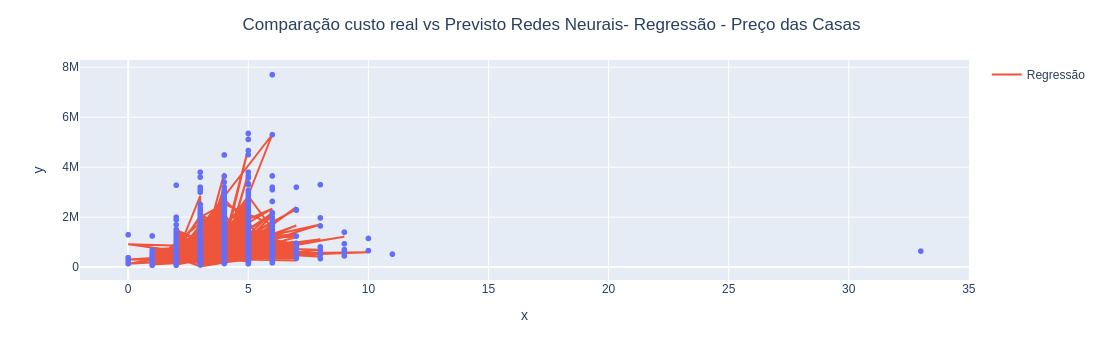

In [194]:

grafico = px.scatter(x = X_casas_treinamento[:, 0].ravel(), y = y_casas_treinamento.ravel())
grafico.add_scatter(x = X_casas_teste[:, 0].ravel(), y = previsoes_inverse.ravel(), name = 'Regressão')
grafico.update_layout(
        title=f'Comparação custo real vs Previsto Redes Neurais- Regressão - Preço das Casas',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_svr_regressao_planosaude_9.html")  # valor real o azul, previsto o vermelho regressão